In [ ]:
pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 6.7 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=ba87a084b0b4618ddaa1742ebb7feecbffb420a8695fae3e72842e64dbc1b80e
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [ ]:
from lifelines import KaplanMeierFitter
kmf = KaplanMeierFitter()
from lifelines import CoxPHFitter
coxph=CoxPHFitter()
from lifelines.exceptions import ConvergenceError
import random
import numpy as np
import time
import math
import pandas as pd

df_record={}

def c(a, b):
    return np.concatenate((a, b))

def rep(val, n):
    return np.ones(n,)*val

def sum_v_2d(x):
    # mat[i,j] = sum(x[i:j+1])
    cumsum = np.cumsum(x)
    mat_1=cumsum[None, :] - cumsum[:-1, None]
    mat = np.concatenate((cumsum[None, :], mat_1), axis=0)
    return np.triu(mat)

def mono_haz(df1_y1, df1_cov1, df1_delta, df1_truncation, adjust, beta_hat):
    z_k = np.unique(np.sort(c(df1_y1, df1_truncation)))
    z1 = np.unique(np.sort(df1_y1[df1_delta==1]))
    N = z_k.shape[0]
    death_sum = np.zeros(N,)
    risk_set = np.zeros(N,)
    exp_term = np.zeros(N,)
    lamda = np.zeros(N,)
    for h in range(N):
      #index = np.logical_and(df1_y1>=z_k[h], df1_truncation<=z_k[h])
        index = np.logical_and(df1_y1>z_k[h], df1_truncation<=z_k[h])
        risk_set[h] = np.sum(index)
        death_sum[h] = np.sum(z1==z_k[h])
        exp_term[h] = np.sum(np.exp(df1_cov1[index] * beta_hat))

    difference = np.diff(z_k)
    nom_2d = sum_v_2d(death_sum[:-1])
    if adjust:
        denom_2d = sum_v_2d(exp_term[:-1] * difference)
    else:
        denom_2d = sum_v_2d(risk_set[:-1] * difference)
    ratio_2d = nom_2d / (denom_2d + 1e-4*(denom_2d==0))

    for j in range(N-1):
        lamda[j] = np.max(np.min(ratio_2d[0:j+1, j:N-1], axis=1), axis=0)
    lamda[N-1] = lamda[N-2]
    return lamda, z_k
def mono_haz_breslow(df1_y1, df1_cov1, df1_delta, df1_truncation, adjust, beta_hat):
    z_k = np.unique(np.sort(c(df1_y1, df1_truncation)))
    z1 = np.unique(np.sort(df1_y1[df1_delta==1]))
    N = z_k.shape[0]

    death_sum = np.zeros(N,)
    risk_set = np.zeros(N,)
    exp_term = np.zeros(N,)
    lamda = np.zeros(N,)

    for h in range(N):
        index = np.logical_and(df1_y1>z_k[h], df1_truncation<=z_k[h])
        risk_set[h] = np.sum(index)
        death_sum[h] = np.sum(z1==z_k[h])
        exp_term[h] = np.sum(np.exp(df1_cov1[index] * beta_hat))

    difference = np.diff(z_k)

    # --- GRENANDER / BRESLOW MODIFICATION START ---

    # 1. Compute the raw Breslow hazard increments first: d(y_k) / sum(exp(...))
    if adjust:
        # Added 1e-8 to prevent division by zero in empty risk sets
        breslow_inc = death_sum[:-1] / (exp_term[:-1] + 1e-8 * (exp_term[:-1] == 0))
    else:
        breslow_inc = death_sum[:-1] / (risk_set[:-1] + 1e-8 * (risk_set[:-1] == 0))

    # 2. Numerator is now the sum of Breslow increments (Lambda_n(v_{s+1}) - Lambda_n(v_r))
    nom_2d = sum_v_2d(breslow_inc)

    # 3. Denominator is simply the sum of time differences (v_{s+1} - v_r)
    denom_2d = sum_v_2d(difference)

    # --- GRENANDER / BRESLOW MODIFICATION END ---

    ratio_2d = nom_2d / (denom_2d + 1e-8 * (denom_2d == 0))

    for j in range(N-1):
        lamda[j] = np.max(np.min(ratio_2d[0:j+1, j:N-1], axis=1), axis=0)

    lamda[N-1] = lamda[N-2]

    return lamda, z_k
def baseline_survival_sim(t1, df1_y1, df1_cov1, df1_delta, df1_truncation, hazard_est):
    z_k = np.unique(np.sort(c(df1_y1, df1_truncation)))
    I = np.digitize(np.array([t1]), bins=z_k, right=True)-1
    first = np.concatenate((np.zeros(1), np.cumsum(np.diff(z_k) * hazard_est[:-1])))
    if I == -1:
        cumhaz1 = 0
        rest=0
    else:
        cumhaz1 = first[I]
        rest = (t1-z_k[I]) * hazard_est[I]
    integration = cumhaz1 + rest
    return np.exp(-integration)

def rweibull(n, shape, scale):
    return scale * np.random.weibull(a=shape, size=(n, ))

def med_weibull(shape,scale):
    return((-np.log(0.5))^(1/shape)*scale)


In [ ]:
def main(a,x_time,x_q1,x_q3,n_trials,n_samples_old,method_i,modify=False, no_est=False,trun_scale=1200):
    surv_median_est = []
    surv_median_tsai = []
    surv_median_lopuha = []
    surv_median_breslow = []
    km_med=np.zeros(n_trials,)
    cox_med=np.zeros(n_trials,)
    elapsed = 0
    save_data={"y1":[], "truncation":[], "cov1":[], "delta":[],
                "tsai_weibull":[], "wu_weibull":[], "lopuha_weibull":[],
                "surv_res_est":[], "surv_res_tsai":[],"surv_res_lopuha":[],
               "surv_res_breslow":[],"breslow_weibull":[],
               "tsai_zk":[], "wu_zk":[], "lopuha_zk":[],"breslow_zk":[],
               "death_sum":[],"exp_term":[]
               }
    min_t = None
    min_x = None
    cox_index=[118, 122, 133, 164, 209, 240, 254, 309, 323, 334, 369, 375, 390,400, 463, 524,
            553, 621, 668, 692, 699, 725, 739, 777, 892, 977, 1030, 1033, 1069, 1164, 1200,
            1244, 1268, 1299, 1303, 1349, 1389, 1399, 1514, 1554, 1602, 1653, 1734, 1744,
            1749, 1756, 1775, 1798, 1866, 1910, 1916, 1974, 1983, 2072, 2093, 2119, 2140,
            2218, 2279, 2436, 2438, 2446, 2513, 2521, 2536, 2645, 2674, 2737, 2788, 2897,
            2945, 2991, 2996, 3012, 3020, 3072, 3088, 3115, 3135, 3153, 3175, 3284, 3303,
            3321, 3506, 3560, 3576, 3638, 3658, 3667, 3744, 3745, 3789, 3852, 3897, 3913,
            3940, 3945, 3960, 3966, 4037, 4055, 4073, 4110, 4133, 4151, 4191, 4217, 4298,
            4329, 4431, 4489, 4549, 4584, 4586, 4601, 4615, 4645, 4707, 4756, 4757, 4789,
            4796, 4908, 4984, 5022, 5024, 5046, 5080, 5114, 5246, 5383, 5469, 5555, 5584,
            5597, 5646, 5705, 5778, 5779, 5810, 5826, 5828, 5883, 5912, 5953, 5974, 5988,
            5996, 6007, 6107, 6113, 6203, 6207, 6212, 6244, 6328, 6387, 6474, 6476, 6547,
            6667, 6669, 6688, 6723, 6783, 6809, 6860, 6869, 6943, 7049, 7078, 7168, 7184,
            7224, 7277, 7390, 7405, 7419, 7434, 7576, 7595, 7646, 7654, 7729, 7772, 7964,
            8005, 8022, 8025, 8061, 8133, 8170, 8171, 8189, 8204, 8276, 8281, 8365, 8427,
            8449, 8498, 8502, 8553, 8680, 8819, 8823, 8944, 8954, 9024, 9048, 9076, 9091,
            9092, 9135, 9146, 9165, 9214, 9242, 9347, 9352, 9372, 9400, 9414, 9430, 9453,
            9471, 9560, 9562, 9681, 9695, 9751, 9772, 9927, 9928, 9988, 10005, 10017, 10085,
            10110, 10169, 10282, 10319, 10336, 10339, 10356, 10362, 10383, 10417, 10443,
            10484, 10507, 10554, 10565, 10577, 10583, 10639, 10675, 10738, 10753, 10842,
            10916, 10919, 10958, 11055, 11091, 11118, 11125, 11130, 11190, 11201, 11204,
            11208, 11290, 11398, 11439, 11450, 11452, 11473, 11572, 11595, 11744, 11796,
            11797, 11845, 11848, 11882, 11894, 11900, 11918, 11925, 11964, 12167, 12338,
            12403, 12431, 12541, 12603, 12696, 12708, 12768, 12773, 12789, 12886, 12929,
            12972, 13171, 13182, 13187, 13287, 13298, 13307, 13348, 13350, 13366, 13415,
            13426, 13451, 13455, 13480, 13536, 13583, 13587, 13680, 13737, 13739, 13774,
            13824, 13825, 13870, 13927, 13946, 13999, 14104, 14115, 14195, 14265, 14286,
            14301, 14321, 14385, 14430, 14437, 14445, 14581, 14586, 14595, 14596, 14637,
            14685, 14696, 14711, 14722, 14725, 14747, 14757, 14796, 14798, 14806, 14826,
            14846, 14885, 14889, 14915, 14938, 14988, 15001, 15216, 15244, 15261, 15331,
            15416, 15522, 15557, 15594, 15610, 15665, 15694, 15705, 15742, 15744, 15797,
            15851, 15884, 15887, 15890, 15988, 16004, 16014, 16016, 16035, 16120, 16252,
            16345, 16421, 16452, 16464, 16475, 16489, 16490, 16504, 16707, 16761, 16773,
            16859, 16968, 17001, 17129, 17232, 17285, 17377, 17494, 17556, 17624, 17650,
            17846, 17902, 17923, 17982, 18082, 18088, 18091, 18099, 18107, 18121, 18132,
            18142, 18147, 18227, 18328, 18396, 18400, 18460, 18540, 18674, 18709, 18740,
            18822, 18855, 18870, 18873, 18938, 18982, 19094, 19136, 19197, 19212, 19239,
            19322, 19332, 19365, 19385, 19386, 19526, 19598, 19602, 19655, 19669, 19688,
            19742, 19749, 19756, 19770, 19877, 19900, 19922,20070, 20072, 20096, 20122,
            20166, 20205, 20243, 20262, 20326, 20333, 20452, 20492, 20590, 20613, 20626,
            20705, 20738, 20740, 20826, 20870, 20905, 20909, 20946, 21060, 21074, 21094,
            21120, 21169, 21184, 21227, 21251, 21264, 21274, 21289, 21291, 21325, 21343,
            21373, 21437, 21514, 21564, 21593, 21594, 21609, 21635, 21701, 21713, 21766,
            21916, 21959, 22012, 22036, 22079, 22086, 22122, 22135, 22270, 22329, 22429,
            22446, 22516, 22553, 22701, 22751, 22768, 22827, 22832, 22834, 22887, 22899,
            23137, 23143, 23166, 23200, 23219, 23251, 23280, 23314, 23324, 23368, 23446,
            23535, 23570, 23591, 23597, 23640, 23659, 23678, 23728, 23730, 23738, 23741,
            23743, 23762, 23844, 23867, 23879, 23903, 23964, 23969, 24066, 24128, 24230,
            24247, 24291, 24349, 24386, 24414, 24433, 24435, 24479, 24626, 24643, 24826,
            24827, 24833, 24840, 24967, 25053, 25066, 25128, 25133, 25143, 25194, 25215,
            25299, 25313, 25364, 25368, 25602, 25647, 25656, 25673, 25691, 25736,
            25800, 25862, 25893, 25997, 26049, 26085, 26087, 26155, 26190, 26195,
            26287, 26289, 26340, 26371, 26421, 26489, 26497, 26499, 26518, 26558,
            26706, 26723, 26761, 26793, 26799, 26826, 26829, 26837, 26915, 26922,
            26930, 26952, 26994, 27039, 27121, 27166, 27188, 27233, 27237, 27272,
            27334, 27343, 27361, 27435, 27456, 27483, 27504, 27509, 27754, 27834,
            27884, 27902, 27933, 27949, 27955, 27986, 27998, 28074, 28089, 28114,
            28146, 28175, 28177, 28277, 28328, 28483, 28494, 28502, 28538, 28712,
            28789, 28856, 28857, 28892, 28910, 28949, 28972, 29021, 29022, 29220,
            29237, 29308, 29336, 29351, 29368, 29370, 29372, 29406, 29442, 29482,
            29505, 29586, 29689, 29713, 29714, 29741, 29743, 29746, 29796, 29852,
            29893, 29984, 30028, 30042, 30119, 30134, 30154, 30255, 30296, 30349,
            30400, 30410, 30419, 30424, 30527, 30617, 30679, 30729, 30757, 30779,
            30816, 30834, 30891, 30900, 30917, 30947, 30968, 30973, 31001, 31019,
            31067, 31128, 31174, 31261, 31274, 31293, 31411, 31527, 31552, 31580,
            31604, 31651, 31658, 31660, 31704, 31865, 31871, 31998, 32030, 32044,
            32263, 32292, 32303, 32311, 32348, 32388, 32593, 32710, 32748, 32828,
            32847, 32859, 32863, 32920, 32992, 33049, 33225, 33258, 33381, 33395,
            33409, 33427, 33451, 33515, 33543, 33588, 33603, 33605, 33763, 33863,
            33917, 33926, 33930, 33953, 33966, 33991, 34003, 34090, 34111, 34120,
            34121, 34150, 34169, 34190, 34303, 34309, 34334, 34343, 34368, 34393,
            34423, 34473, 34511, 34526, 34594, 34656, 34724, 34785, 34830, 34848,
            34867, 34887, 34941, 34964, 34984, 35018, 35035, 35094, 35158, 35215,
            35234, 35258, 35270, 35307, 35320, 35342, 35345, 35374, 35421, 35457,
            35489, 35555, 35560, 35561, 35625, 35728, 35839, 35917, 35995, 36018,
            36056, 36167, 36201, 36292, 36295, 36305, 36309, 36335, 36374, 36467,
            36476, 36574, 36647, 36861, 36883, 36960, 36961, 36988, 37010, 37139,
            37195, 37333, 37380, 37433, 37447, 37479, 37494, 37547, 37628, 37634,
            37665, 37695, 37740, 37758, 37780, 37786, 37809, 37837, 37942, 37956,
            38030, 38038, 38064, 38085, 38178, 38180, 38189, 38230, 38240, 38329,
            38390, 38410, 38434, 38437, 38487, 38497, 38498, 38603, 38610, 38617,
            38688, 38720, 38752, 38766, 38790, 38814, 38885, 38906, 38910, 38934,
            38995, 39054, 39070, 39076, 39132, 39144, 39268, 39278, 39293, 39333,
            39352, 39364, 39380, 39523, 39528, 39536, 39537, 39564, 39588, 39601,
            39639, 39672, 39701, 39703, 39916, 39943, 40026, 40089, 40096, 40183,
            40189, 40256, 40323, 40481, 40571, 40594, 40601, 40651, 40733, 40738,
            40778, 40833, 40882, 41025, 41054, 41079, 41116, 41144, 41165, 41225,
            41251, 41273, 41275, 41301, 41372, 41405, 41441, 41491, 41506, 41527,
            41754, 41761, 41786, 41791, 41921, 41922, 41926, 41968, 42037, 42048,
            42077, 42129, 42167, 42228, 42327, 42364, 42367, 42418, 42476, 42479,
            42494, 42523, 42572, 42585, 42685, 42697, 42740, 42764, 42772,45003,
            45046, 45114, 45157, 45227, 45244, 45296, 45359, 45385, 45453, 45536,
            45561, 45567, 45632, 45667, 45687, 45700, 45718, 45811, 45819, 45825,
            45843, 45847, 45874, 45924,46044, 46124, 46151, 46217, 46268, 46284,
            46368, 46399, 46418, 46471, 46480, 46516, 46560, 46571, 46597, 46634,
            46693, 46724, 46725, 46740, 46761, 46878, 46968, 46982, 47080, 47191,
            47198, 47254, 47294, 47312, 47335, 47342, 47525, 47531, 47570, 47641,
            47748, 47845, 47915, 47946, 48070, 48091, 48118, 48138, 48227, 48277,
            48320, 48533, 48536, 48538, 48562, 48565, 48566, 48584, 48612, 48718,
            48837, 48871, 49027, 49035, 49124, 49128, 49189, 49194, 49204, 49224,
            49257, 49378, 49406, 49453, 49487, 49497, 49541, 49551, 49557, 49639,
            49723, 49861, 49889, 50128, 50154, 50159, 50161, 50324, 50339, 50373,
            50500, 50503, 50531, 50546, 50607, 50613, 50650, 50713, 50756, 50788,
            50803, 50861, 50906]
    #cox_index=[20070, 20072, 20096, 20122, 20166, 20205, 20243, 20262, 20326, 20333, 20452, 20492, 20590, 20613, 20626, 20705, 20738, 20740, 20826, 20870, 20905, 20909, 20946, 21060, 21074, 21094, 21120, 21169, 21184, 21227, 21251, 21264, 21274, 21289, 21291, 21325, 21343, 21373, 21437, 21514, 21564, 21593, 21594, 21609, 21635, 21701, 21713, 21766, 21916, 21959, 22012, 22036, 22079, 22086, 22122, 22135, 22270, 22329, 22429, 22446, 22516, 22553, 22701, 22751, 22768, 22827, 22832, 22834, 22887, 22899, 23137, 23143, 23166, 23200, 23219, 23251, 23280, 23314, 23324, 23368, 23446, 23535, 23570, 23591, 23597, 23640, 23659, 23678, 23728, 23730, 23738, 23741, 23743, 23762, 23844, 23867, 23879, 23903, 23964, 23969, 24066, 24128, 24230, 24247, 24291, 24349, 24386, 24414, 24433, 24435, 24479, 24626, 24643, 24826, 24827, 24833, 24840, 24967, 25053, 25066, 25128, 25133, 25143, 25194, 25215, 25299, 25313, 25364, 25368, 25602, 25647, 25656, 25673, 25691, 25736, 25800, 25862, 25893, 25997, 26049, 26085, 26087, 26155, 26190, 26195, 26287, 26289, 26340, 26371, 26421, 26489, 26497, 26499, 26518, 26558, 26706, 26723, 26761, 26793, 26799, 26826, 26829, 26837, 26915, 26922, 26930, 26952, 26994, 27039, 27121, 27166, 27188, 27233, 27237, 27272, 27334, 27343, 27361, 27435, 27456, 27483, 27504, 27509, 27754, 27834, 27884, 27902, 27933, 27949, 27955, 27986, 27998, 28074, 28089, 28114, 28146, 28175, 28177, 28277, 28328, 28483, 28494, 28502, 28538, 28712, 28789, 28856, 28857, 28892, 28910, 28949, 28972, 29021, 29022, 29220, 29237, 29308, 29336, 29351, 29368, 29370, 29372, 29406, 29442, 29482, 29505, 29586, 29689, 29713, 29714, 29741, 29743, 29746, 29796, 29852, 29893, 29984, 30028, 30042, 30119, 30134, 30154, 30255, 30296, 30349, 30400, 30410, 30419, 30424, 30527, 30617, 30679, 30729, 30757, 30779, 30816, 30834, 30891, 30900, 30917, 30947, 30968, 30973, 31001, 31019, 31067, 31128, 31174, 31261, 31274, 31293, 31411, 31527, 31552, 31580, 31604, 31651, 31658, 31660, 31704, 31865, 31871, 31998, 32030, 32044, 32263, 32292, 32303, 32311, 32348, 32388, 32593, 32710, 32748, 32828, 32847, 32859, 32863, 32920, 32992, 33049, 33225, 33258, 33381, 33395, 33409, 33427, 33451, 33515, 33543, 33588, 33603, 33605, 33763, 33863, 33917, 33926, 33930, 33953, 33966, 33991, 34003, 34090, 34111, 34120, 34121, 34150, 34169, 34190, 34303, 34309, 34334, 34343, 34368, 34393, 34423, 34473, 34511, 34526, 34594, 34656, 34724, 34785, 34830, 34848, 34867, 34887, 34941, 34964, 34984, 35018, 35035, 35094, 35158, 35215, 35234, 35258, 35270, 35307, 35320, 35342, 35345, 35374, 35421, 35457, 35489, 35555, 35560, 35561, 35625, 35728, 35839, 35917, 35995, 36018, 36056, 36167, 36201, 36292, 36295, 36305, 36309, 36335, 36374, 36467, 36476, 36574, 36647, 36861, 36883, 36960, 36961, 36988, 37010, 37139, 37195, 37333, 37380, 37433, 37447, 37479, 37494, 37547, 37628, 37634, 37665, 37695, 37740, 37758, 37780, 37786, 37809, 37837, 37942, 37956, 38030, 38038, 38064, 38085, 38178, 38180, 38189, 38230, 38240, 38329, 38390, 38410, 38434, 38437, 38487, 38497, 38498, 38603, 38610, 38617, 38688, 38720, 38752, 38766, 38790, 38814, 38885, 38906, 38910, 38934, 38995, 39054, 39070, 39076, 39132, 39144, 39268, 39278, 39293, 39333, 39352, 39364, 39380, 39523, 39528, 39536, 39537, 39564, 39588, 39601, 39639, 39672, 39701, 39703, 39916, 39943, 40026, 40089, 40096, 40183, 40189, 40256, 40323, 40481, 40571, 40594, 40601, 40651, 40733, 40738, 40778, 40833, 40882, 41025, 41054, 41079, 41116, 41144, 41165, 41225, 41251, 41273, 41275, 41301, 41372, 41405, 41441, 41491, 41506, 41527, 41754, 41761, 41786, 41791, 41921, 41922, 41926, 41968, 42037, 42048, 42077, 42129, 42167, 42228, 42327, 42364, 42367, 42418, 42476, 42479, 42494, 42523, 42572, 42585, 42685, 42697, 42740, 42764, 42772, 42853, 42868, 42881, 42957, 43107, 43128, 43263, 43287, 43373, 43491, 43495, 43500, 43518, 43534, 43582, 43591, 43631, 43642, 43666, 43697, 43848, 43917, 43926, 43949, 44012, 44032, 44080, 44215, 44276, 44350, 44373, 44390, 44402, 44450, 44467, 44477, 44584, 44625, 44711, 44719, 44799, 44804, 44888, 44971, 44982]
    dataframe_list=[]
    sample_size=[]
    tsai_size=[]
    error_index=[]
    cox_fail_index=[]
    for i in range(len(cox_index)):
        tt1 = time.time()
        #seed_num=i+46000
        seed_num=cox_index[i]
        np.random.seed(seed_num)
        n_samples = n_samples_old
        man1=rweibull(n_samples//2, shape=a, scale = 1000)
        cen1=rweibull(n_samples//2, shape=a, scale = 1000)
        woman2=rweibull(n_samples//2, shape=a, scale = 2000)
        cen2=rweibull(n_samples//2, shape=a, scale = 2000)
        censor=c(cen1, cen2)
        failure = c(man1, woman2)
        cov1 = c(rep(0, n_samples//2), rep(1, n_samples//2))
        delta = failure <= censor
        y1 = delta * failure + (1-delta) * censor
        n_tried=0
        while n_tried<5000:
          n_tried+=1
          man1  =rweibull(n_samples//2, shape=a, scale = 1000)
          cen1=rweibull(n_samples//2, shape=a, scale = 1000)
          woman2=rweibull(n_samples//2, shape=a, scale = 2000)
          cen2=rweibull(n_samples//2, shape=a, scale = 2000)
          censor=c(cen1, cen2)
          failure = c(man1, woman2)
          cov1 = c(rep(0, n_samples//2), rep(1, n_samples//2))
          delta = failure <= censor
          y1 = delta * failure + (1-delta) * censor
          truncation = rweibull(n_samples, shape=4, scale=3000)
          full_data = pd.DataFrame({
            'y1': y1, 'truncation': truncation,'delta': delta,'cov1': cov1
          })
          early_candidates = full_data[(full_data['truncation'] < 200)&
                                        (full_data['truncation'] <= full_data['y1'])]
          early_selected = early_candidates.head(3)

          if len(early_selected) > 1:
            break
        remaining_data = full_data[
            (full_data['truncation'] <= full_data['y1']) &
            (~(full_data.index.isin(early_selected.index)))
        ]
        main_data = remaining_data.sample(1000-early_selected.shape[0], replace=False) #np.random.choice(remaining_data, 100)
        concat_main_data = pd.concat([early_selected, main_data])
        #indices = concat_main_data.index.values
        y1 = concat_main_data['y1'].values
        cov1 = concat_main_data['cov1'].values
        delta = concat_main_data['delta'].values
        truncation = concat_main_data['truncation'].values
        n_samples = len(truncation)

        truncation0 = np.zeros(n_samples)
        d = {'y1': y1, 'truncation': truncation,'delta': delta,'cov1': cov1, "trial_i":i+cov1*0}
        df2 = pd.DataFrame(data=d)
        # df_record[i] = df2.copy()
        # dataframe_list.append(df_record[i])
        if no_est:
            print("Trial", i)
            continue
        bashaz_index=np.digitize(x_time, bins=np.sort(y1), right=True)-1
        try:
            coxph.fit(df=df2,duration_col="y1",event_col="delta",entry_col='truncation',formula="cov1")
            coxph.fit(df=df2,duration_col="y1",event_col="delta",formula="cov1")
        except (ConvergenceError, ValueError) as e:
            print(f"⚠️ Warning: Cox model failed with error: {e}")
            error_index.append(i)
        try:
            coxph.fit(df=df2,duration_col="y1",event_col="delta",formula="cov1")
        except (ConvergenceError, ValueError) as e:
            print(f"⚠️ Warning: Cox model failed with error: {e}")
            if i not in error_index:
                error_index.append(i)
        if i not in error_index:
            coxph.fit(df=df2,duration_col="y1",event_col="delta",entry_col='truncation',formula="cov1")
            beta_hat_wu=coxph.params_.iloc[0]
            coxph.fit(df=df2,duration_col="y1",event_col="delta",formula="cov1")
            beta_hat_lopuha=coxph.params_.iloc[0]
            death_sum=np.zeros(n_samples,)
            exp_term=np.zeros(n_samples,)
            z_k = np.unique(np.sort(y1))
            #z1 = np.unique(np.sort(full_data.loc[full_data['delta'] == 1, 'y1']))
            z1 = np.unique(np.sort(y1[delta==1]))
            #print("DEBUG n_tried=%d len(z_k)=%d  len(z1)=%d   n_samples=%d   len(y1)=%d"%(n_tried, len(z_k), len(z1), n_samples, len(y1)))
            for l in range(n_samples):
                index = np.logical_and(y1>=z_k[l], truncation<=z_k[l])
                death_sum[l] = np.sum(z1==z_k[l])
                exp_term[l] = np.sum(np.exp(cov1[index] * beta_hat_wu))

            #if cox_med[i]<0.3:
            cox_est=np.where(bashaz_index==-1, 1, np.exp(-np.cumsum(death_sum/exp_term))[bashaz_index])
            if cox_est>0:
            #if cox_est<0.3:
                cox_fail_index.append(i)
                cox_med[i]=np.where(bashaz_index==-1, 1, np.exp(-np.cumsum(death_sum/exp_term))[bashaz_index])
                tsai_weibull, tsai_zk = mono_haz(y1[cov1==0], cov1[cov1==0], delta[cov1==0], truncation[cov1==0],
                                      adjust=False, beta_hat=0)
              #tsai_weibull, tsai_zk = mono_haz(y1[cov1==1], cov1[cov1==1], delta[cov1==1], truncation[cov1==1],
              #                      adjust=False, beta_hat=0)
                wu_weibull, wu_zk = mono_haz(y1, cov1, delta, truncation, adjust=True, beta_hat=beta_hat_wu)
                lopuha_weibull, lopuha_zk = mono_haz(y1, cov1, delta, truncation0, adjust=True, beta_hat=beta_hat_lopuha)
                breslow_weibull, breslow_zk = mono_haz_breslow(y1, cov1, delta, truncation, adjust=True, beta_hat=beta_hat_wu)
                dataframe_list.append(df2.copy())
                if min_t is None:
                    min_t = np.min([np.max(tsai_zk), np.max(wu_zk),np.max(lopuha_zk)])
                else:
                    min_t = np.min([min_t, np.max(tsai_zk), np.max(wu_zk),np.max(lopuha_zk)])
                if min_x is None:
                    min_x = np.min(y1)
                else:
                    min_x = np.min([min_x, np.min(y1)])
                surv_res_est=baseline_survival_sim(x_time, y1, cov1, delta,truncation,hazard_est=wu_weibull)
                # surv_res_est_wmn=surv_res_est**(np.exp(beta_hat_wu))
                surv_median_est.append(surv_res_est)
                #surv_median_est.append(surv_res_est_wmn)
                surv_res_lopuha=baseline_survival_sim(x_time, y1, cov1, delta,truncation0,hazard_est=lopuha_weibull)
                surv_median_lopuha.append(surv_res_lopuha)
                surv_res_breslow=baseline_survival_sim(x_time, y1, cov1, delta,truncation,hazard_est=breslow_weibull)
                surv_median_breslow.append(surv_res_breslow)
                surv_res_tsai=baseline_survival_sim(x_time, y1[cov1==0], cov1[cov1==0], delta[cov1==0], truncation[cov1==0],hazard_est=tsai_weibull)
                #surv_res_tsai=baseline_survival_sim(x_time, y1[cov1==1], cov1[cov1==1], delta[cov1==1], truncation[cov1==1],hazard_est=tsai_weibull)
                surv_median_tsai.append(surv_res_tsai)
                dt = time.time() - tt1
                elapsed += dt
                eta = (n_trials - i - 1) * (elapsed / (i+1))
                save_data["y1"].append(y1)
                save_data["tsai_zk"].append(tsai_zk)
                save_data["wu_zk"].append(wu_zk)
                save_data["cov1"].append(cov1)
                save_data["truncation"].append(truncation)
                save_data["delta"].append(delta)
                save_data["tsai_weibull"].append(tsai_weibull)
                save_data["wu_weibull"].append(wu_weibull)
                save_data["lopuha_weibull"].append(lopuha_weibull)
                save_data["breslow_weibull"].append(breslow_weibull)
                save_data["surv_res_est"].append(surv_res_est)
                save_data["surv_res_lopuha"].append(surv_res_lopuha)
                save_data["surv_res_tsai"].append(surv_res_tsai)
                save_data["surv_res_breslow"].append(surv_res_breslow)
                save_data["death_sum"].append(death_sum)
                save_data["exp_term"].append(exp_term)
                i1=len(surv_median_est)-1
                print("Trials:%04d/%04d  dt:%.3fs  elapsed:%.3fs  ETA:%.3fs|beta.hat.wu:%.4f beta.hat.lopuha:%.4f| OUTPUT=wu:%.4f tsai:%.4f lopuha:%.4f breslow:%.4f cox:%.4f km:%.4f"%(i,
                n_trials, dt, elapsed, eta,beta_hat_wu,beta_hat_lopuha ,surv_res_est.item(),
                surv_res_tsai.item(),surv_res_lopuha.item(),surv_res_breslow.item(),cox_med[i].item(),km_med[i].item()))
                print("min_x:%.4f min_t:%.4f  valid_n:%4d tsai_n:%4d"%(min_x, min_t, n_samples,len(y1[cov1==0])))
                sample_size.append(n_samples)
                tsai_size.append(len(y1[cov1==0]))
    if no_est==False:
          filtered_cox_med=cox_med[cox_fail_index]
          #print(cox_med_)
          print("#"*40)
          print(error_index)
          print("#"*40)
          print(cox_fail_index)
          print("#"*40)
          print(len(surv_median_est))
          print("#"*40)
          print(filtered_cox_med)
          print("#"*40)
          #| %.4f | %.4f
          print("Summary (med):   bias: %.4f| %.4f| %.4f| %.4f| %.4f variance: %.4f| %.4f| %.4f| %.4f| %.4f avg_n:%4d|avg_tsai_n:%4d"%(
              np.mean(surv_median_est)-0.5,np.mean(surv_median_tsai)-0.5,np.mean(surv_median_lopuha)-0.5,np.mean(surv_median_breslow)-0.5,
              np.mean(filtered_cox_med)-0.5,#np.mean(km_med)-0.5,
              np.std(surv_median_est,ddof=1),np.std(surv_median_tsai,ddof=1),np.std(surv_median_lopuha,ddof=1),np.std(surv_median_breslow,ddof=1),
              np.std(filtered_cox_med,ddof=1),#np.std(km_med,ddof=1),
              np.mean(sample_size),np.mean(tsai_size)
          ))


    # save data
    from google.colab import drive
    drive.mount('/content/drive')
    if no_est==False:
        np.savez("/content/drive/My Drive/data_monotone_hazard.npz", data=save_data)
    pd.concat(dataframe_list).to_csv('/content/drive/My Drive/df_concat.csv')

if __name__ == "__main__":
    main(a=4, x_time=912.4443,x_q1=1231.839,x_q3=569.7305,n_trials=1124,n_samples_old=100000,no_est=False)


Trials:0000/1124  dt:3.455s  elapsed:3.455s  ETA:3880.433s|beta.hat.wu:-3.4330 beta.hat.lopuha:-5.0248| OUTPUT=wu:0.2604 tsai:0.2314 lopuha:0.6911 breslow:0.0000 cox:0.1185 km:0.0000
min_x:298.9804 min_t:1234.8170  valid_n:1000 tsai_n:  57


/usr/local/lib/python3.12/dist-packages/lifelines/fitters/coxph_fitter.py:1679: RuntimeWarning: overflow encountered in exp
  scores = weights * exp(dot(X, beta))
/usr/local/lib/python3.12/dist-packages/lifelines/fitters/coxph_fitter.py:1733: RuntimeWarning: invalid value encountered in multiply
  a1 = risk_phi_x_x * denom
/usr/local/lib/python3.12/dist-packages/lifelines/fitters/coxph_fitter.py:1735: RuntimeWarning: invalid value encountered in multiply
  summand = numer * denom[:, None]
/usr/local/lib/python3.12/dist-packages/lifelines/fitters/coxph_fitter.py:1740: RuntimeWarning: divide by zero encountered in log
  log_lik = log_lik + dot(x_death_sum, beta) + weighted_average * log(denom).sum()
/usr/local/lib/python3.12/dist-packages/lifelines/fitters/coxph_fitter.py:1679: RuntimeWarning: overflow encountered in exp
  scores = weights * exp(dot(X, beta))
/usr/local/lib/python3.12/dist-packages/lifelines/fitters/coxph_fitter.py:1733: RuntimeWarning: invalid value encountered in multi

⚠️ Warning: Cox model failed with error: Convergence halted due to matrix inversion problems. Suspicion is high collinearity. Please see the following tips in the lifelines documentation: https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-convergence-in-the-cox-proportional-hazard-modelMatrix is singular.
⚠️ Warning: Cox model failed with error: Convergence halted due to matrix inversion problems. Suspicion is high collinearity. Please see the following tips in the lifelines documentation: https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-convergence-in-the-cox-proportional-hazard-modelMatrix is singular.
Trials:0002/1124  dt:4.350s  elapsed:7.806s  ETA:2916.807s|beta.hat.wu:-3.1991 beta.hat.lopuha:-4.7541| OUTPUT=wu:0.4158 tsai:0.4744 lopuha:0.7433 breslow:0.3124 cox:0.2913 km:0.0000
min_x:298.9804 min_t:1234.8170  valid_n:1000 tsai_n:  63
Trials:0003/1124  dt:3.176s  elapsed:10.981s  ETA:3074.811s|beta.hat.wu:-2.9616 beta.hat.lopuha:-4.5985| O

/usr/local/lib/python3.12/dist-packages/lifelines/fitters/coxph_fitter.py:1679: RuntimeWarning: overflow encountered in exp
  scores = weights * exp(dot(X, beta))
/usr/local/lib/python3.12/dist-packages/lifelines/fitters/coxph_fitter.py:1733: RuntimeWarning: invalid value encountered in multiply
  a1 = risk_phi_x_x * denom
/usr/local/lib/python3.12/dist-packages/lifelines/fitters/coxph_fitter.py:1735: RuntimeWarning: invalid value encountered in multiply
  summand = numer * denom[:, None]
/usr/local/lib/python3.12/dist-packages/lifelines/fitters/coxph_fitter.py:1740: RuntimeWarning: divide by zero encountered in log
  log_lik = log_lik + dot(x_death_sum, beta) + weighted_average * log(denom).sum()
/usr/local/lib/python3.12/dist-packages/lifelines/fitters/coxph_fitter.py:1679: RuntimeWarning: overflow encountered in exp
  scores = weights * exp(dot(X, beta))
/usr/local/lib/python3.12/dist-packages/lifelines/fitters/coxph_fitter.py:1733: RuntimeWarning: invalid value encountered in multi

⚠️ Warning: Cox model failed with error: Convergence halted due to matrix inversion problems. Suspicion is high collinearity. Please see the following tips in the lifelines documentation: https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-convergence-in-the-cox-proportional-hazard-modelMatrix is singular.
⚠️ Warning: Cox model failed with error: Convergence halted due to matrix inversion problems. Suspicion is high collinearity. Please see the following tips in the lifelines documentation: https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-convergence-in-the-cox-proportional-hazard-modelMatrix is singular.
Trials:0010/1124  dt:4.127s  elapsed:32.572s  ETA:3295.710s|beta.hat.wu:-2.6613 beta.hat.lopuha:-4.1947| OUTPUT=wu:0.4065 tsai:0.4094 lopuha:0.7590 breslow:0.3387 cox:0.2747 km:0.0000
min_x:298.9804 min_t:1234.8170  valid_n:1000 tsai_n:  59


...

⚠️ Warning: Cox model failed with error: Convergence halted due to matrix inversion problems. Suspicion is high collinearity. Please see the following tips in the lifelines documentation: https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-convergence-in-the-cox-proportional-hazard-modelMatrix is singular.
⚠️ Warning: Cox model failed with error: Convergence halted due to matrix inversion problems. Suspicion is high collinearity. Please see the following tips in the lifelines documentation: https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-convergence-in-the-cox-proportional-hazard-modelMatrix is singular.
Trials:0976/1124  dt:3.051s  elapsed:2910.899s  ETA:437.976s|beta.hat.wu:-3.0473 beta.hat.lopuha:-4.5367| OUTPUT=wu:0.4537 tsai:0.4639 lopuha:0.7892 breslow:0.2271 cox:0.2989 km:0.0000
min_x:108.3389 min_t:1162.1786  valid_n:1000 tsai_n:  60
Trials:0977/1124  dt:4.133s  elapsed:2915.032s  ETA:435.168s|beta.hat.wu:-3.2036 beta.hat.lopuha:-4.6273

/usr/local/lib/python3.12/dist-packages/lifelines/fitters/coxph_fitter.py:1679: RuntimeWarning: overflow encountered in exp
  scores = weights * exp(dot(X, beta))
/usr/local/lib/python3.12/dist-packages/lifelines/fitters/coxph_fitter.py:1733: RuntimeWarning: invalid value encountered in multiply
  a1 = risk_phi_x_x * denom
/usr/local/lib/python3.12/dist-packages/lifelines/fitters/coxph_fitter.py:1735: RuntimeWarning: invalid value encountered in multiply
  summand = numer * denom[:, None]
/usr/local/lib/python3.12/dist-packages/lifelines/fitters/coxph_fitter.py:1740: RuntimeWarning: divide by zero encountered in log
  log_lik = log_lik + dot(x_death_sum, beta) + weighted_average * log(denom).sum()
/usr/local/lib/python3.12/dist-packages/lifelines/fitters/coxph_fitter.py:1679: RuntimeWarning: overflow encountered in exp
  scores = weights * exp(dot(X, beta))
/usr/local/lib/python3.12/dist-packages/lifelines/fitters/coxph_fitter.py:1733: RuntimeWarning: invalid value encountered in multi

⚠️ Warning: Cox model failed with error: Convergence halted due to matrix inversion problems. Suspicion is high collinearity. Please see the following tips in the lifelines documentation: https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-convergence-in-the-cox-proportional-hazard-modelMatrix is singular.
⚠️ Warning: Cox model failed with error: Convergence halted due to matrix inversion problems. Suspicion is high collinearity. Please see the following tips in the lifelines documentation: https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-convergence-in-the-cox-proportional-hazard-modelMatrix is singular.
Trials:0982/1124  dt:4.021s  elapsed:2928.463s  ETA:420.054s|beta.hat.wu:-2.9379 beta.hat.lopuha:-4.4058| OUTPUT=wu:0.3710 tsai:0.3747 lopuha:0.7583 breslow:0.2748 cox:0.2654 km:0.0000
min_x:108.3389 min_t:1162.1786  valid_n:1000 tsai_n:  57
Trials:0983/1124  dt:3.069s  elapsed:2931.532s  ETA:417.088s|beta.hat.wu:-2.7409 beta.hat.lopuha:-4.3712

/usr/local/lib/python3.12/dist-packages/lifelines/fitters/coxph_fitter.py:1679: RuntimeWarning: overflow encountered in exp
  scores = weights * exp(dot(X, beta))
/usr/local/lib/python3.12/dist-packages/lifelines/fitters/coxph_fitter.py:1731: RuntimeWarning: divide by zero encountered in divide
  denom = 1.0 / np.array([risk_phi])
/usr/local/lib/python3.12/dist-packages/lifelines/fitters/coxph_fitter.py:1733: RuntimeWarning: invalid value encountered in multiply
  a1 = risk_phi_x_x * denom
/usr/local/lib/python3.12/dist-packages/lifelines/fitters/coxph_fitter.py:1735: RuntimeWarning: invalid value encountered in multiply
  summand = numer * denom[:, None]
/usr/local/lib/python3.12/dist-packages/lifelines/fitters/coxph_fitter.py:1740: RuntimeWarning: divide by zero encountered in log
  log_lik = log_lik + dot(x_death_sum, beta) + weighted_average * log(denom).sum()
/usr/local/lib/python3.12/dist-packages/lifelines/fitters/coxph_fitter.py:1740: RuntimeWarning: invalid value encountered i

⚠️ Warning: Cox model failed with error: Convergence halted due to matrix inversion problems. Suspicion is high collinearity. Please see the following tips in the lifelines documentation: https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-convergence-in-the-cox-proportional-hazard-modelMatrix is singular.
⚠️ Warning: Cox model failed with error: Convergence halted due to matrix inversion problems. Suspicion is high collinearity. Please see the following tips in the lifelines documentation: https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-convergence-in-the-cox-proportional-hazard-modelMatrix is singular.
Trials:0999/1124  dt:3.228s  elapsed:2984.247s  ETA:370.047s|beta.hat.wu:-3.1663 beta.hat.lopuha:-5.0178| OUTPUT=wu:0.4024 tsai:0.4040 lopuha:0.7581 breslow:0.1685 cox:0.2619 km:0.0000
min_x:108.3389 min_t:1162.1786  valid_n:1000 tsai_n:  55
Trials:1000/1124  dt:3.184s  elapsed:2987.430s  ETA:367.087s|beta.hat.wu:-2.7556 beta.hat.lopuha:-4.2561

#Code for figure1

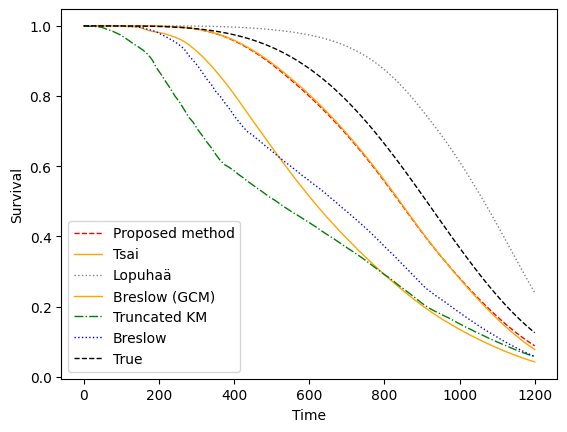

In [ ]:
# visualization
#times = np.linspace(110, 1190, 100)
# times = np.linspace(0, 1196, 100)
#times = np.linspace(0, 2052, 100)
a=4
true_prob=np.exp(-(times/1000)**a)
wu_avg = np.mean(np.array(wu_item_list), axis=-1)
tsai_avg = np.mean(np.array(tsai_item_list), axis=-1)
lopuha_avg = np.mean(np.array(lopuha_item_list), axis=-1)
breslow_avg = np.mean(np.array(breslow_item_list), axis=-1)
#km_avg = np.mean(np.array(km_item_list), axis=-1)
km_prob = pd.read_csv("/content/drive/My Drive/km.csv");
cox_avg = np.mean(np.array(cox_item_list), axis=-1)
linewidth=1
plt.plot(times, wu_avg, label="Proposed method", color="red", linestyle="--",linewidth=linewidth)
plt.plot(times, tsai_avg, label="Tsai", color="orange", linestyle="-", linewidth=linewidth)
plt.plot(times, lopuha_avg, label="Lopuhaä", color="grey", linestyle=":", linewidth=linewidth)
plt.plot(times, breslow_avg, label="Breslow (GCM)", color="orange", linestyle="-", linewidth=linewidth)
plt.plot(times, km_prob['mean.km'], label="Truncated KM", color="green", linestyle="-.", linewidth=linewidth)
plt.plot(times, cox_avg, label="Breslow", color="blue", linestyle=":", linewidth=linewidth)
plt.plot(times, true_prob, label="True", color="black", linestyle='--', linewidth=linewidth)
#plt.title('shape=4; trun=1200; bias: 0.0332| 0.0340| -0.1458   MCSE: 0.0702| 0.0720| 0.1831; N=1000', fontsize=10)

plt.legend()
plt.xlabel("Time")
plt.ylabel("Survival")
plt.show()
#'km_avg':km_avg,
#result_df = pd.DataFrame(data={'wu_avg': wu_avg, 'tsai_avg': tsai_avg,'lopuha_avg': lopuha_avg,'cox_avg': cox_avg,'true_prob': true_prob})
# save data
#from google.colab import drive
#drive.mount('/content/drive')
#result_df.to_csv('/content/drive/My Drive/result_df.csv')